In [9]:
# RetailOps 360 | Customer Segmentation — RFM Analysis
# Author: Mohammad Ali Rafique
# Dataset: Olist Brazilian E-Commerce

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

path = r'C:\Users\Ali\Downloads\New folder (4)'

orders   = pd.read_csv(f'{path}\\olist_orders_dataset.csv')
items    = pd.read_csv(f'{path}\\olist_order_items_dataset.csv')

# Parse dates
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Filter — delivered orders, Jan 2017 to Sep 2018
orders = orders[
    (orders['order_status'] == 'delivered') &
    (orders['order_purchase_timestamp'] >= '2017-01-01') &
    (orders['order_purchase_timestamp'] <  '2018-10-01')
].copy()

print(f"Delivered orders: {len(orders):,}")


Delivered orders: 96,211


In [10]:
# Reference date — day after last order in dataset
reference_date = orders['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Merge orders with spend
order_spend = items.groupby('order_id')['price'].sum().reset_index()
order_spend.columns = ['order_id', 'order_value']

orders = orders.merge(order_spend, on='order_id', how='left')

# Calculate RFM per customer
rfm = orders.groupby('customer_id').agg(
    recency   = ('order_purchase_timestamp',
                 lambda x: (reference_date - x.max()).days),
    frequency = ('order_id', 'nunique'),
    monetary  = ('order_value', 'sum')
).reset_index()

rfm['monetary'] = rfm['monetary'].round(2)

print(f"Total customers: {len(rfm):,}")
print(f"\nRFM Summary:")
print(rfm[['recency','frequency','monetary']].describe().round(2))

Total customers: 96,211

RFM Summary:
       recency  frequency  monetary
count 96211.00   96211.00  96211.00
mean    238.87       1.00    137.00
std     151.18       0.00    209.11
min       1.00       1.00      0.85
25%     116.00       1.00     45.90
50%     220.00       1.00     86.50
75%     349.00       1.00    149.90
max     602.00       1.00  13440.00


In [11]:
# Score each metric 1-4 (4 = best)
rfm['R_score'] = pd.qcut(rfm['recency'],   q=4,
                          labels=[4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'),
                          q=4, labels=[1,2,3,4]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'],  q=4,
                          labels=[1,2,3,4]).astype(int)

# Combined RFM score
rfm['RFM_score'] = rfm['R_score'].astype(str) + \
                   rfm['F_score'].astype(str) + \
                   rfm['M_score'].astype(str)

rfm['total_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

print(rfm[['customer_id','recency','frequency',
           'monetary','R_score','F_score',
           'M_score','total_score']].head(10))

                        customer_id  recency  frequency  monetary  R_score  \
0  00012a2ce6f8dcda20d059ce98491703      288          1     89.80        2   
1  000161a058600d5901f007fab4c27140      410          1     54.90        1   
2  0001fd6190edaaf884bcaf3d49edf079      548          1    179.99        1   
3  0002414f95344307404f0ace7a26f1d5      379          1    149.90        1   
4  000379cdec625522490c315e70c7a9fb      150          1     93.00        3   
5  0004164d20a9e969af783496f3408652      505          1     59.99        1   
6  000419c5494106c306a97b5635748086      180          1     34.30        3   
7  00046a560d407e99b969756e0b10f282      255          1    120.90        2   
8  00050bf6e01e69d5c0fd612f1bcfb69c      346          1     69.99        2   
9  000598caf2ef4117407665ac33275130       19          1   1107.00        4   

   F_score  M_score  total_score  
0        1        3            6  
1        1        2            4  
2        1        4            6  
3

In [12]:
def assign_segment(row):
    r = row['R_score']
    f = row['F_score']
    m = row['M_score']
    score = row['total_score']

    if r == 4 and f >= 3:
        return 'Champion'
    elif r >= 3 and f >= 2:
        return 'Loyal'
    elif r == 4 and f == 1:
        return 'New Customer'
    elif r >= 3 and score >= 7:
        return 'Potential Loyalist'
    elif r == 2 and f >= 2:
        return 'At Risk'
    elif r == 1 and f >= 2:
        return 'Lost Loyal'
    elif score <= 4:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

segment_summary = (
    rfm.groupby('segment')
    .agg(
        customer_count = ('customer_id', 'count'),
        avg_recency    = ('recency',    'mean'),
        avg_frequency  = ('frequency',  'mean'),
        avg_monetary   = ('monetary',   'mean'),
        total_revenue  = ('monetary',   'sum')
    )
    .round(2)
    .sort_values('total_revenue', ascending=False)
    .reset_index()
)

print(segment_summary.to_string(index=False))

           segment  customer_count  avg_recency  avg_frequency  avg_monetary  total_revenue
             Loyal           24101       140.70           1.00        135.82     3273287.83
           At Risk           18122       279.26           1.00        137.13     2485126.56
        Lost Loyal           17972       450.77           1.00        136.32     2450023.80
          Champion           11963        58.26           1.00        140.29     1678311.49
   Needs Attention           10468       295.47           1.00        152.25     1593718.45
      New Customer            6103        59.28           1.00        140.23      855819.40
Potential Loyalist            2941       168.14           1.00        225.27      662519.84
              Lost            4541       392.53           1.00         40.13      182219.76


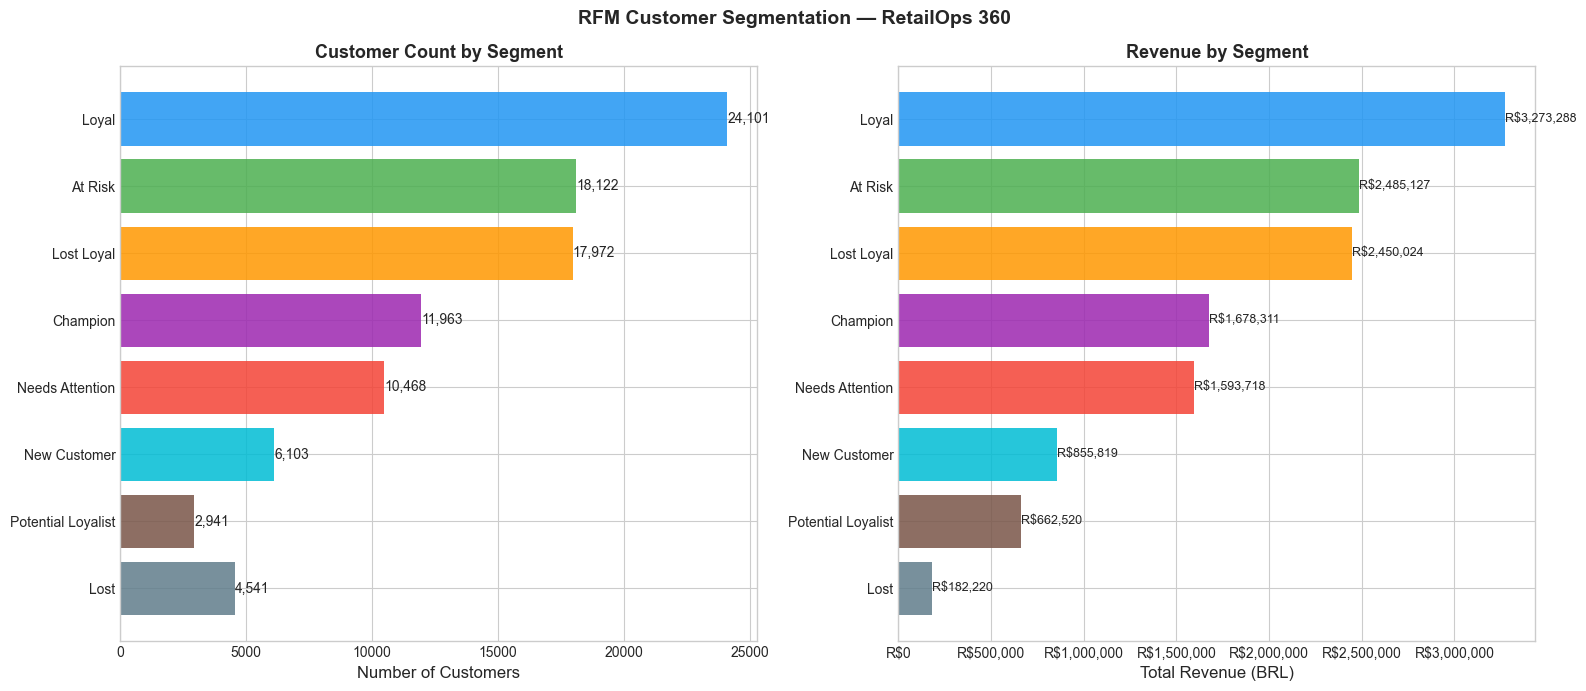

Chart saved successfully


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors = ['#2196F3','#4CAF50','#FF9800',
          '#9C27B0','#F44336','#00BCD4','#795548','#607D8B']

# Left — customer count per segment
axes[0].barh(
    segment_summary['segment'],
    segment_summary['customer_count'],
    color=colors[:len(segment_summary)], alpha=0.85
)
axes[0].set_xlabel('Number of Customers', fontsize=12)
axes[0].set_title('Customer Count by Segment', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
for i, (bar, val) in enumerate(zip(axes[0].patches,
                                    segment_summary['customer_count'])):
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=10)

# Right — revenue per segment
axes[1].barh(
    segment_summary['segment'],
    segment_summary['total_revenue'],
    color=colors[:len(segment_summary)], alpha=0.85
)
axes[1].set_xlabel('Total Revenue (BRL)', fontsize=12)
axes[1].set_title('Revenue by Segment', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
for bar, val in zip(axes[1].patches, segment_summary['total_revenue']):
    axes[1].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                 f'R${val:,.0f}', va='center', fontsize=9)

plt.suptitle('RFM Customer Segmentation — RetailOps 360',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{path}\\rfm_segments.png', dpi=150)
plt.show()
print("Chart saved successfully")

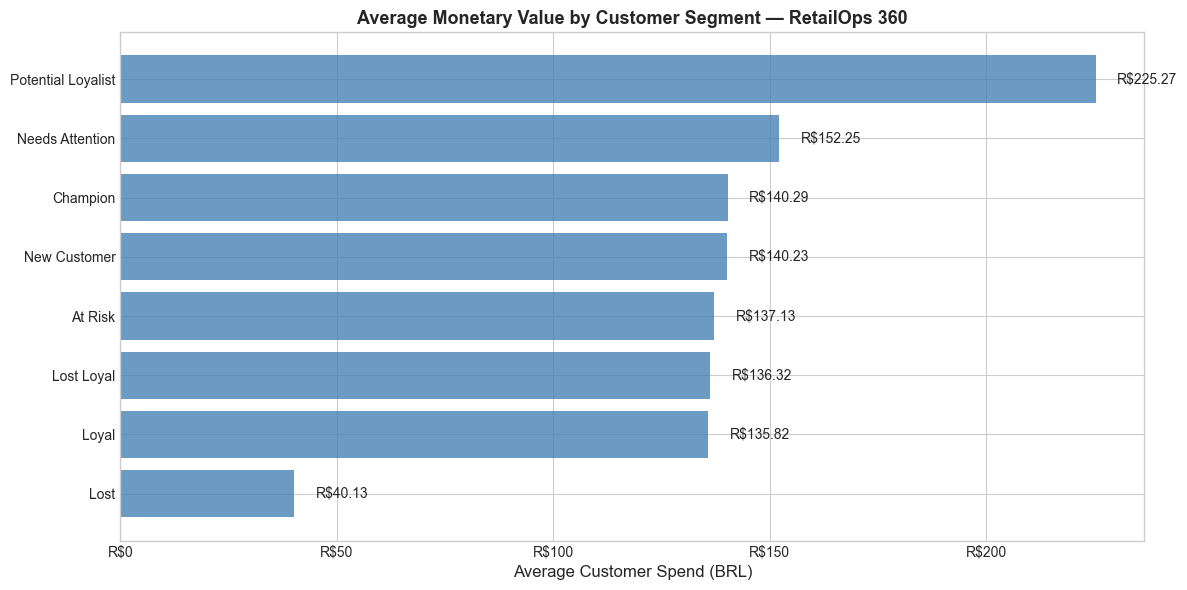

Chart saved successfully


In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

seg_sorted = segment_summary.sort_values('avg_monetary', ascending=True)

bars = ax.barh(seg_sorted['segment'], seg_sorted['avg_monetary'],
               color='steelblue', alpha=0.8)

for bar, val in zip(bars, seg_sorted['avg_monetary']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'R${val:,.2f}', va='center', fontsize=10)

ax.set_xlabel('Average Customer Spend (BRL)', fontsize=12)
ax.set_title('Average Monetary Value by Customer Segment — RetailOps 360',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))

plt.tight_layout()
plt.savefig(f'{path}\\rfm_avg_spend.png', dpi=150)
plt.show()
print("Chart saved successfully")